# Barvna slika

## Osnove za Phyton

In [2]:
'''
  Main folder/
  ├── Data/Barvna slika
  |         ├── BIAS/
  |         │   └── ... .fits
  |         ├── DARK/
  |         │   └── ... .fits
  |         ├── FLAT/
  |         │   └── ... .fits
  |         └── LIGHT/
  |             ├── M 1/
  |             │   └── ... .fits
  |             ├── M 13/
  |             │   └── ... .fits
  |             ├── M 51/
  |             │   └── ... .fits
  |             ├── M 57/
  |             │   └── ... .fits
  |             └── M 101/
  |                 └── ... .fits
  │
  └── barvna_slika_master.ipynb (To bereš zdaj)
'''
pass

In [3]:
from astropy.io import fits # modul za delo s fits posnetki
import matplotlib.pyplot as plt # modul za risanje grafov
import numpy as np # modul za numerične operacije
import astroalign # modul za poravnavo astronomskih posnetkov
import glob # Modul za brskanje po mapah
import os
import ipywidgets as widgets
from ipywidgets import interact
from IPython.display import clear_output

In [4]:
folder =  os.path.join(os.path.abspath(''), "..", "Data")


## Astrofotografija

### Barve v astronomiji

Dajmo takoj razjasnit, da "prave" barve ne obstajajo. Barva je način naše interpretacije svetlobe različnih valovnih dolžin in jo lahko definiramo na mnogo načinov. Za astronoma je barva definirana kot razmerje svetlosti objekta pri eni valovni dolžini proti svetlosti objekta pri drugi valovni dolžini. V tej vaji želimo iz posnetkov meglice M27 narejenih pri različnih valovnih dolžinah izdelati sliko, ki bo predvsem prijetna na pogled. Pozabili bomo torej na stroge definicije barv in se raje posvetili tehničnim izzivom izdelave barvne slike. Na koncu bomo vseno pokomentirali kakšne informacije nosijo različne barve na naših slikah.

Vsi detektorji svetlobe v vseh digitalnih kamerah na tem svetu znajo izmerit le intenziteto svetlobe in ne njene barve, frekvence, valovne dolžine ali energije fotonov. Informacijo o barvah dobimo tako, da sliko objekta posnamemo skozi različne barvne filtre. Barvni filtri prepuščajo le fotone v ozkem območju valovnih dolžin (torej pri neki barvi). Če pred detektor postavimo barvni filter, lahko izmerjeno intenziteto svetlobe interpretiramo kot svetlost objekta v tisti barvi. 

Kamere za vsakodnevno rabo lahko izmerijo intenziteto skozi tri barvne filtre (rdečega, zelenega in modrega) naenkrat. To dosežejo tako, da so piksli na detektorju izmenično prekriti z rdečim, zelenim ali modrim filtrom. Vsak piksel je torej prekrit le z enim od teh filtrov. Da kamera bolje simulira barvno informacijo, ki jo zbere naše oko, ki je najbolj občutljivo na zeleno svetlobo, je polovica pikslov prekritih z zelenim filtrom 1/4 pikslov z modrim in 1/4 z rdečim filtrom. 

<figure>
<img src="figures/kamera.png" width="500"/>      <img src="figures/zaslon.png" alt="zaslon pod mikroskopom" width="422"/>
<figcaption align = "center"> Levo: barvna kamera pod mikroskopom. Desno: računalniški zaslon pod mikroskopom </figcaption>
</figure>

Vsakdanje kamere nam ne dajo izbire filtrov. Uporabiti moramo tiste, ki so prilepljeni na detektor. To je prevelika omejitev za astronomske potrebe, kjer bi radi imeli več svobode pri izbiri filtra. V astronomiji zato najpogosteje uporabimo kamero, ki nimam na detektor prilepljene nobene matrike filtrov. Sliko objekta nato posnamemo skozi barvni filter, ki prekrije cel detektor. To ponovimo z vsemi barvnimi filtri, s katerimi želimo posneti objekt. Astronomski objekti se (z izjemami) spreminjajo ali premikajo počasi, zato lahko isti objekt posnamemo z drugim filtrom ob kasnejšem času. Pri klasični fotografiji si ne bi mogli privoščit menjat filtre in delat zaporedne posnetke, saj bi se naš objekt ta čas premaknil. Rekonstruirana barvna slika bi bila popačena in barve premaknjene. 

Digitalno sliko moramo seveda tudi prikazati. Omejimo se na prikaz na digitalnih zaslonih. Zasloni, tako kot kamere, ne morejo menjavati barve posameznega piksla. Vsak piksel zaslona je v resnici sestavljen iz treh manjših podpikslov, en lahko prikazuje različne nivoje modre svetlobe, drugi zelene in tretji rdeče. To zlahka vidimo s povečevalnim steklom al pa pod kapljico vode na zaslonu. Na digitalnih zaslonih je torej enostavno prikazati posnetke narejene z digitalno kamero. Intenziteta vsake od treh barv na pikslu slike se pretvori v intenziteto treh barvnih podpikslov na zaslonu.

Sliko, ki jo je kamera naredila skozi modre, zelene in rdeče filtre lahko torej prikažemo še kar verodostojno na zaslonu, ki prav tako uporablja modre, zelene in rdeče piksle. Ampak astronomski detektor lahko posname sliko skozi katerikoli filter, rumen, infrardeč, UV, itd. Kako torej prikažemo tako sliko, saj ne moremo za vsako kombinacijo filtrov imeti posebnega zaslona? Odgovor je preprost, barve na takem prikazu ne bodo "prave" ali realistične. Sliko še vseeno prikažemo na običajnem zaslonu, vendar se moramo zavedat, da intenziteta modre barve na zaslonu ne odgovarja intenziteti posneti skozi moder filter, ampak skozi nek drug filter. Z modro barvo torej prikažemo svetlost objekta v nekem izbranem filtru. Enako naredimo z drugima dvema barvama, ki ju lahko prikaže zaslon. Tako lahko na zaslonu v vidni svetlobi prikažemo tudi svetlost slike posnete v IR ali UV filtrih. Če nas zanima svetlost objekta le v enem filtru, ne kompliciramo in prikažemo samo sivine (svetlosti modrega, zelenega in rdečeka podpiksla na zaslonu so enake). Če želimo hkrati prikazati svetlost v več filtrih, uporabimo lahko največ tri barve, ki jih ima zaslon na voljo. 

Sedaj je postalo jasno zakaj "prave" barve ne obstajajo. Filter v kameri ne prepušča povsem istih valovnih dolžin kot jih seva piksel na zaslonu. V resnici zmeraj prikažemo z neko barvo svetlost v nekem drugem filtru. Barvni filtri tudi nimajo enake prepustnosti, kot je občutljivost čepkov v našem očesu, zato barve niso nikoli realistične. Tudi občutljivost čepkov variira od človeka do človeka, zato tehnično sploh ne moremo definirati pravih ali realističnih barv.


### Obdelava posnetkov

Digitalna kamera ne more idealno preslikati svetlosti objekta v svetlost slike. Detektor lahko v omejenem času zbere le končno število fotonov. Signal na vsakem pikslu je zato podvržen stohastičnemu šumu, saj je zbiranje fotonov naključen proces. Kdaj piksel zadane več fotonov, kdaj manj. Če bi opazovali nek enakomerno osvetljen objekt in bi pričakovali, da je njegova slika isto svetla v vseh pikslih, bi še vedno zaznali piksle, ki so svetlejši ali temnejši od povprečja. Standardna deviacija števila fotonov je enaka korenu povprečnega števila fotonov
$$\sigma=\sqrt{N}.$$
Slika torej izgleda zašumljena (sosednji piksli variirajo v intenziteti). To lahko popravimo z daljšimi ekspozicijskimi časi, da zberemo več fotonov. Večji $N$ pomeni manjšo relativno standardno deviacijo. 

Zaradi omejitev elektronike, ki zaznano število fotonov pretvori v digitalni signal, ima digitalna slika še nekaj dodatnih šumov. Te lahko v večji meri popravimo, saj lahko izmerimo kakšen je njihov prispevek na sliki. Skupaj s sliko objekta v astronomiji posnamemo še nekaj kalibracijskih slik. Te so posnetek s časom osvetlitve 0 s (rečemo mu tudi nični posnetek ali bias posnetek), posnetek z daljšim časom osvetlitve, a s pokritim teleksopom, ki ne zazna nič svetlobe (temni posnetek ali dark posnetek) in posnetek enakomerno osvetljenega polja, na primer projekcijskega zaslona ali neba ob mraku (posnetek ravnega polja ali flat posnetek). Kako te kalibracijske posnetke uporabimo, se bomo naučili v tej vaji.

Digitalni detektorji tudi niso izdelani brez napak. Nemogoče je zagotoviti, da se pri izdelavi čipa vsi piksli vgravirajo pravilno. Posledica je, da imajo vsi čipi nedelujoče ali slabše občutljive piksle. Nekaj takih napak lahko vsaj vizualno odstranimo z uporabo kalibracijskih posnetkov, druge pa ostanejo na sliki. To zlahka opazimo na astronomskih posnetkih, saj jih izdelamo iz surove informacije o signalu na vsakem pikslu. Napak ne opazimo na posnetkih narejenih s telefonom, na primer. Slika, ki jo naredi telefon, gre skozi ogromno obdelave, v današnjem času tudi skozi prste umetne inteligence, da se napake in slaba kvaliteta drobne kamere v telefonu popravijo. Taka sika izgleda lepo, ne more pa nosit verodostojne informacije, ki bi jo zahteval astronom.

Naj omenim še očitno, da v astronomiji shranjujemo slike v formatih, ki ne uporabljajo kompresije. Najpogostejši format v astronomiji je FITS format, ki ga bomo spoznavali v vseh treh vajah.

## Opis vaje

Pri tej vaji imamo na voljo posnetke meglice M27 z imenom Ročka. Posnetki so narejeni skozi različne barvne filtre. Imamo tudi kalibracijske posnetke, ki jih bomo uporabili, da obdelamo posnetke M27. Posnetke M27 narejene v različnih barvah bomo nato združili v barvno sliko. V sledečem primeru obdelamo vse posnetke in združimo posnetke narejen v rdečem, zelenem in modrem filtru. Sami lahko naredite še barvno sliko s kakšno drugo kombinacijo filtrov. 

Svoja opazovanja boste izvedli s teleskopom Zarja in poljubno kombinacijo barvnih filtrov. Cilj vaje je, da spoznate teleskop, inštrumente in delo z astronomskimi posnetki. Naučili se boste tudi osnovnih konceptov teorije barv in prikaza barv na zaslonu. Sami boste sprogramirali nekaj algoritmov za manipulacijo barvnih slik.


## Opazovanja

### Inštrumenti



Pri tej vaji uporabljamo teleskop [ASA AZ-800](https://www.astrosysteme.com/products/asa-az800/) (Zarja) in kamero [C5A-150M](https://www.gxccd.com/art?id=698&cat=1&lang=409). Na voljo boste imeli tudi standarden [set barvnih filtrov](https://www.baader-planetarium.com/en/filters.html?page=1&filter_filters_size%5Bfilter%5D=65+x+65+mm%2C270). 

### Potek opazovanj

Pri tej vaji je kritično, da posnamete dobre kalibracijske posnetke. To je najlažje narediti med mrakom, ko ne vidimo na nebu nobenih zvezd, zato temu primerno planirajte opazovanja. Vaja ne terja dolgotrajnih opazovanj, boste pa z daljšimi opazovanji lahko naredili res fantastične slike vesolja. 

### Nabor posnetkov

Za to vajo imamo na voljo nabor posnetkov v vseh sedmih filtrih, ki so montirani pred kamero na teleskopu Zarja, posnetke narejene brez uporabe filtrov (oziroma s prozornim C filtrom) in kalibracijske posnetke imenovane bias, dark in flat. Slednji kalibracijski posnetki so narejeni z vsakim filtrom posebej. Pri mojih opazovanjih je prišlo do napake in flat posnetki narejeni s C filtrom niso uporabni. Priporočam, da jih ne uporabite. Pri svojih opazovanjih bodite bolj previdni!

| Filter | št. posnetkov | ekspozicijski čas | skupen exp. čas |
| :--------- | :--- | :----- | :----- |
| U          | 10   | 180 s  | 1800 s |
| B          | 8    | 180 s  | 1440 s |
| V          | 5    | 180 s  | 900 s  |
| R          | 5    | 180 s  | 900 s  |
| C          | 5    | 180 s  | 900 s  |
| O III      | 5    | 180 s  | 900 s  |
| H$\alpha$  | 5    | 180 s  | 900 s  |
| S II       | 10   | 180 s  | 1800 s |
| bias       | 5    | 0.1 s$*$ | 0.5 s$*$ |
| dark       | 5    | 180 s  | 900 s  |
| flat U     | 0    | $\dagger$ |     |
| flat B     | 5    | 30 s   | 150 s  |
| flat V     | 5    | 10 s   | 50 s   |
| flat R     | 5    | 2 s    | 10 s   |
| flat C     | 5    | 10 s   | 50 s   |
| flat O III | 5    | 60 s   | 300 s  |
| flat H$\alpha$ | 5 | 60 s  | 300 s  |
| flat S II | 5      | 60 s  | 300 s  |


$*$ Kamera na teleskopu Zarja ne more narediti ekspozicije dolge točno 0s, zato smo naredili ekspozicijo dolgo 0.1 s z zaprto zaslonko.\
$\dagger$ Luč, ki osvetljuje zaslon ne sveti v UV svetlobi, zato flat posnetka s tem filtrom nismo mogli naredit. 

<figure>
<img src="figures/M27.png" width="1200"/>
<figcaption align = "center"> Primer trominutnega posnetka M27. </figcaption>
</figure>


## Obdelava posnetkov

### Posnetki opis

#### Bias posnetki

Ko kamera pretvarja analogni signal (število elektronov shranjenih na vsakem pikslu) v digitalnega, mora analogni signal najprej ojačati in potem preračunati napetost v številko, ki nam poda število zaznanih fotonov. Pri tem lahko pride do napak oziroma šuma in kamera bi lahko izmerila tudi negativni signal, čeprav je zaznala le pozitivno število fotonov. Negativna vrednost bi elektronika interpretirala kot izredno močan signal (overflow). Da se tega problema rešimo, elektronika najprej doda nek majhen umeten signal, ki je enak po celi sliki. Morebitni negativni signali se torej odštevajo od neke znatne vrednosti in ne od nič. Temu dodatnemu signalu rečemo bias ali offset. V astronomiji je pomembne razlog za bias signal tudi linearnost detektorja. Želimo, da večji signal pomeni linearno več zaznanih fotonov. Detektorji in elektronika ne morejo zagotavljati linearnosti pri zelo majhnih signalih, zato signal najprej umetno povečamo. 

Ta umetno dodan bias signal moramo od našega posnetka odšteti. To najlažje naredimo tako, da naredimo ekspozicijo dolgo 0 s (ne zberemo torej nič svetlobe). Ves signal na posnetku je torej le bias in šum, ki je nastal pri prenašanju slike iz detektorja. 

#### Dark posnetki

Poleg fotonov, ki izbijejo elektrone iz valenčnega pasu polprevodnika v detektorju, lahko elektroni spontano preskočijo med plastema. To se zgodi, če ima elektron dovolj termične energije. Vedno v valenčnem pasu obstaja delež elektronov, ki imajo za to dovolj energije. Se pa njihov delež eksponentno zmanjša pri nižjih temperaturah. Ker so ekspozicijski časi v astronomiji veliki, imajo elektroni tudi dovolj časa, da jih znaten delež lahko spontano preskoči iz valenčnega v prevodni pas. To je razlog, da kamere v astronomiji hladimo. Kljub temu moramo sliko popraviti za signal, ki smo ga pridobili iz termičnih elektronov. To storimo tako, da posnamemo sliko z dolgo ekspozicijo a pokritim teleskopom. Detektor torej ne zazna nič svetlobe in ves signal (ki ne pripada bias signalu opisanemu zgoraj) lahko pripišemo termičnim elekronom. tak signal od posnetka odštejemo.

#### Flat posnetki

Celotna površina detektorja ni enakomerno občutljiva za svetlobo. Najbolj na to vpliva prah ali umazanija, ki se nabere na šipi nad detektorjem ali na barvnih filtrih. Pogost razlog je tudi premajhna optika, ki sliko projecira na prevelik detektor. Robovi slike so tako manj osvetljeni kot center. Temu efektu rečemo vinjetiranje.

Občutljivost detektorja normaliziramo tako, da posnamemo sliko enakomerno osvetljenega polja, na primer bel projekcisjki zaslon v kupoli ali sliko večernega ali jutranjega neba. Če bi imeli idealne instrumente, bi dobili enakomerno osvetljen posnetek. Vsa odstopanja od enakomerne osvetljitve nam kažejo manjšo občutljivost detektorja na tistem mestu na sliki. Sliko objekta lahko delimo s takim kalibracijskim posnetkom, da normaliziramo po sliki spreminjajočo se občutljivost.

#### Prikaz posnetka

V astronomiji za shranjevanje posnetkov uporabljamo format [FITS](https://heasarc.gsfc.nasa.gov/docs/heasarc/fits.html). Omogoča format slike, kjer je vrednost signala v vsakem pikslu podana z decimalno številko s poljubno natančnostjo. To je ključno, saj kot smo že nakazali zgoraj, bomo signal na slikah manipulirali in rezultati za signal na vsakem pikslu bodo lahko decimalke ali celo negativne vrednosti. Nič od tega ne morejo zajeti vsakdanji formati, ki jih uporabljamo na spletu, telefonu itd. Ti lahko signal na vsakem pikslu predstavijo le s celoštevilskimi vrednostmi med vključno 0 in 255 za vsako od treh barv. FITS format omogoča tudi shranjevanje sekvence slik, večih posnetkov v isti datoteki (tako lahko shranimo informacijo o barvah) in shranjevanje preprostih tabel. 

Podatkovna struktura FITS posnetka je sestavljena iz t.i. podaljškov (extensions). Vsak vsebuje glavo in podatke. Glava vsebuje informacije o sliki, instrumentih, ki so bili uporabljeni in lahko vsebuje tudi komentarje opazovalca in podobne zaznamke. Podatki so predstavljeni s tabelo števil, kjer vsako polje tabele predstavlja vrednost signala na enem pikslu. Naši posnetki so preprosti in vsebujejo le en podaljšek, torej eno glavo z eno pripadajočo tabelo. 

Poglejmo, kako sliko odpremo, jo preberemo v spomin računalnika in prikažemo. Za branje (in mnogo drugih operacij) bomo uporabili modul <tt>astropy</tt>, za prikaz slike pa modul za risanje grafov <tt>matplotlib</tt>. Na začetku uvozimo še nekaj drugih modulov, ki nam bodo kasneje pomagali pri delu.

### Koda

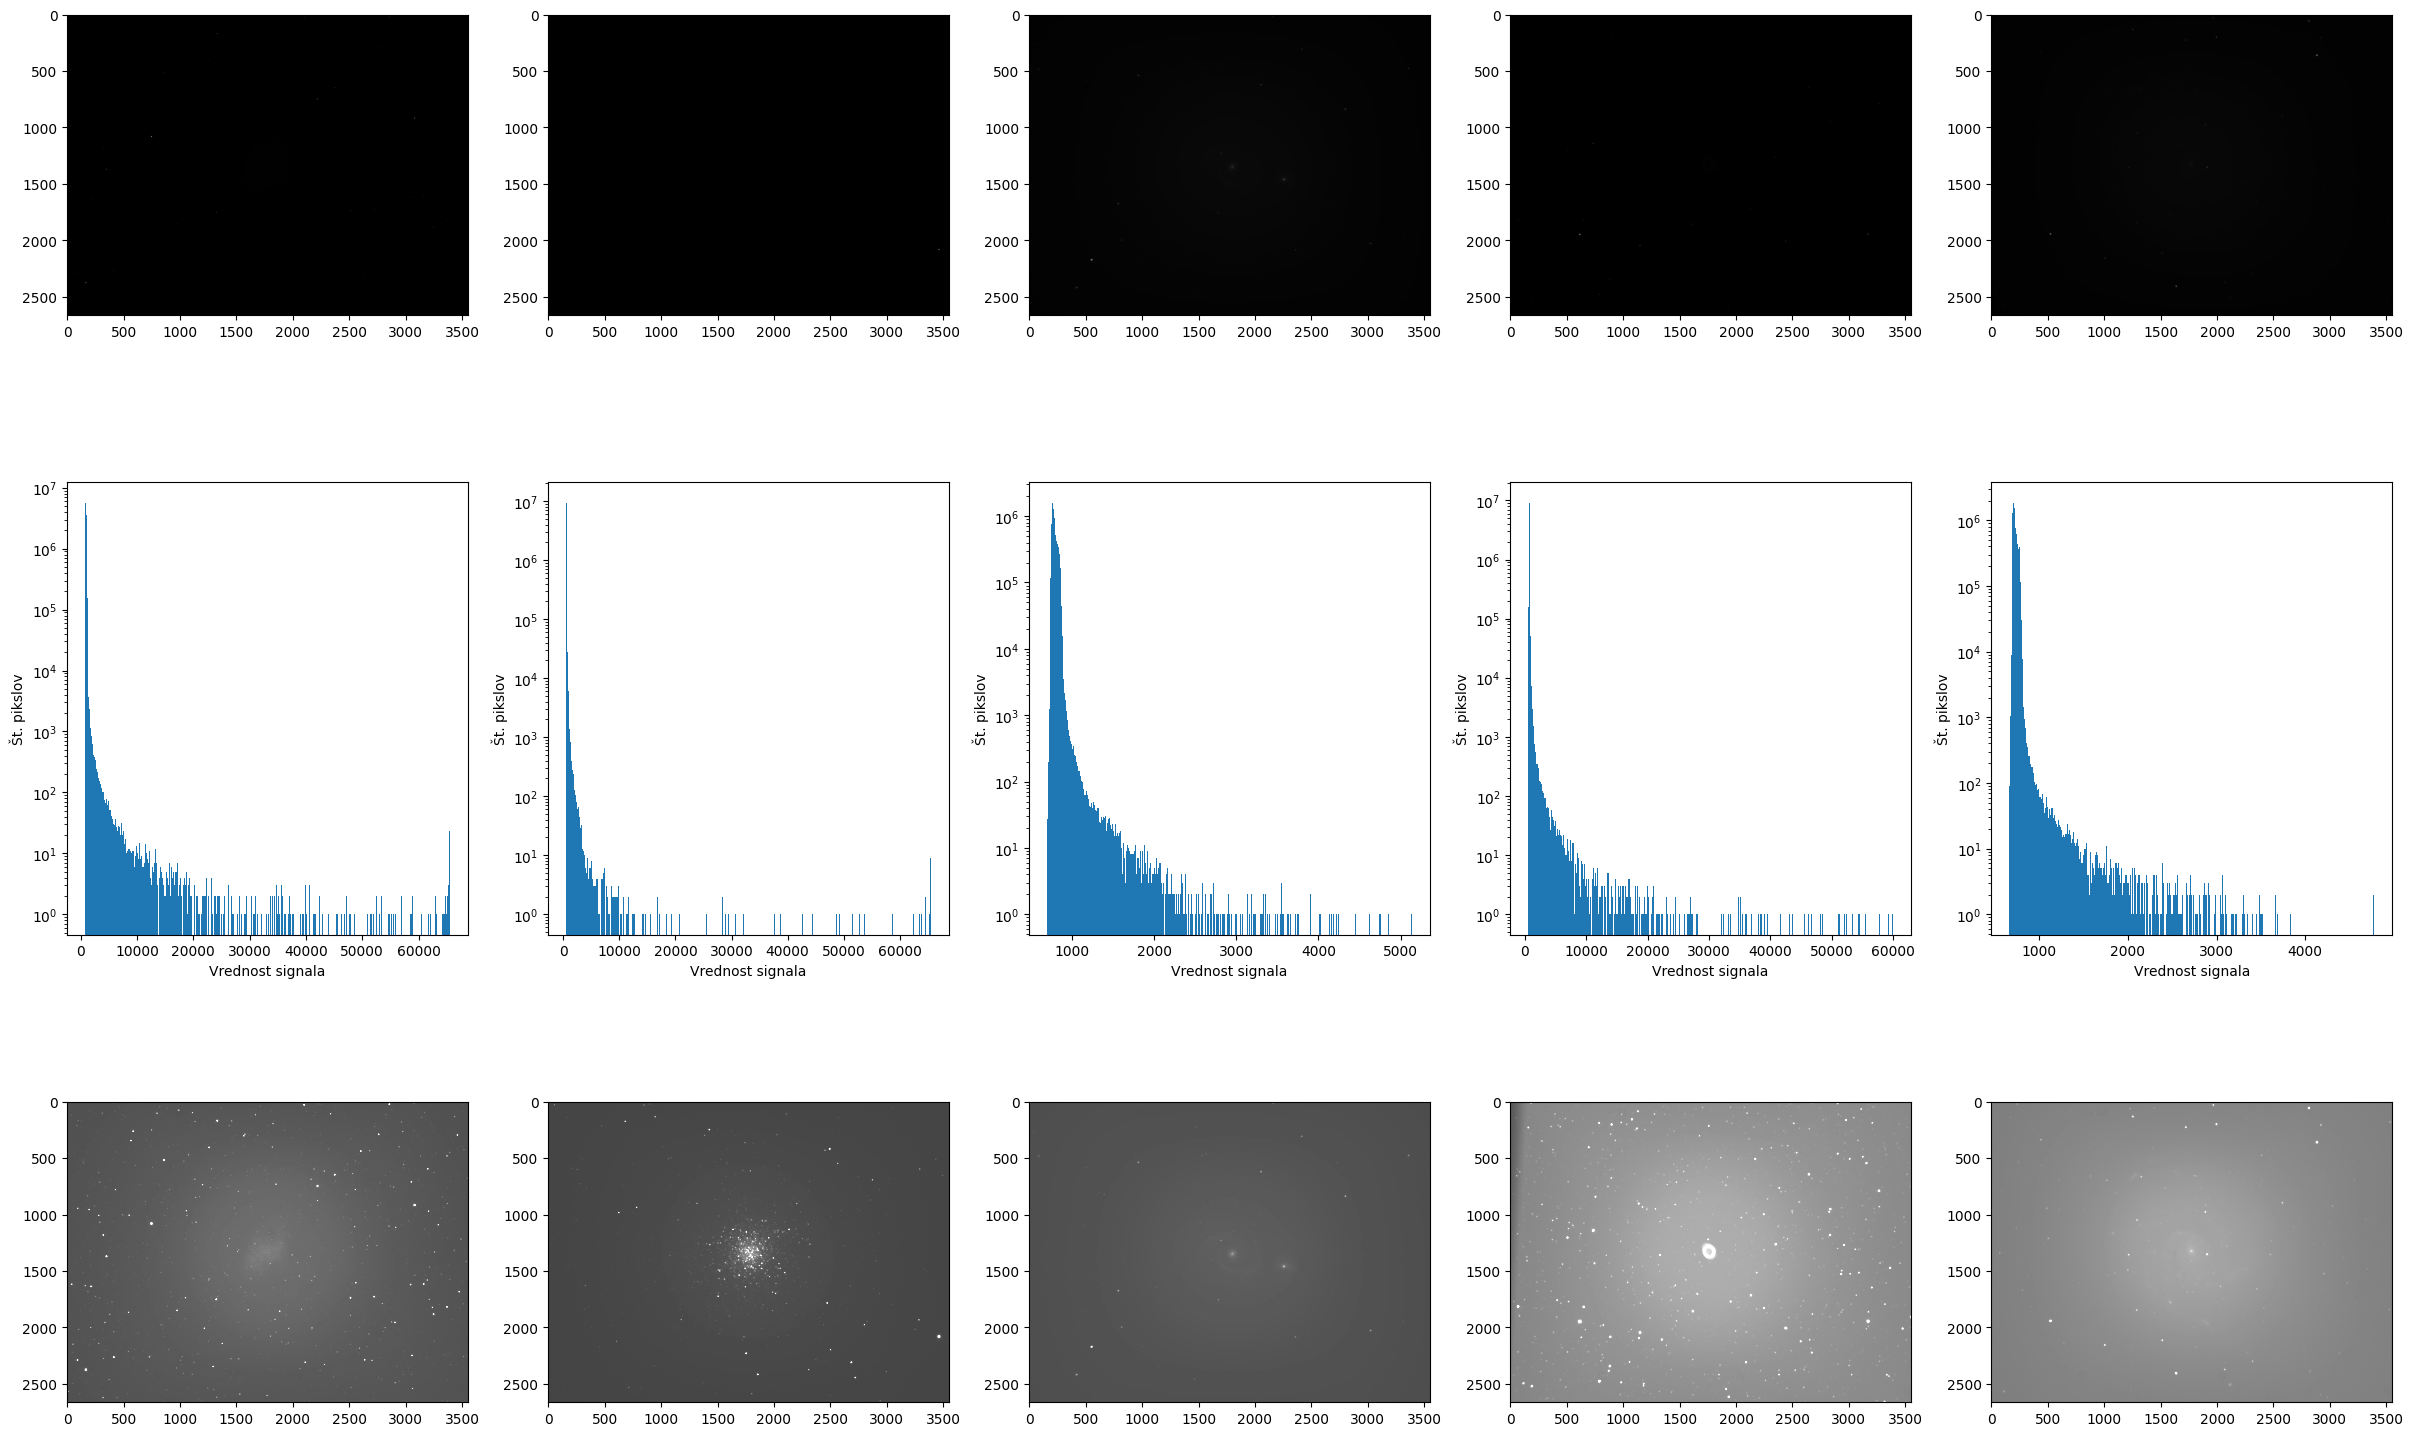

In [4]:
fig, ax = plt.subplots(3, 5, figsize=(30, 20))
images_data = []
for n, i in zip(range(5), [("M 1", "R_180.00_0011.fits", 400, 2000), ("M 13", "R_30.00_0010.fits", 400, 1000), ("M 51", "R_30.00_0000.fits", 200, 2000),
                           ("M 57", "R_30.00_0020.fits", 400, 1000), ("M 101", "R_30.00_0000.fits", 400, 1000)]):
    images_data.append(fits.getdata(os.path.join(folder, "LIGHT", i[0], i[1])))

    # preberemo podatke o sliki iz fits datoteke in prikazemo podatke kot sliko
    ax[0, n].imshow(images_data[n], cmap = 'gray')
    
    ax[1, n].hist(images_data[n].flatten(), bins = 500, log = True)
    ax[1, n].set_xlabel('Vrednost signala')
    ax[1, n].set_ylabel('Št. pikslov')
    ax[2, n].imshow(images_data[n], cmap='gray', vmin = i[2], vmax = i[3], norm= "linear")

Na prikazani sliki žal ničesar ne vidimo. Naša kamera namreč lahko zazna veliko večji dinamični razpon svetlosti, kot ga lahko prikaže naš zaslon oziroma ta notebook. Naša slika ima $65\,536=2^{16}$ različnih nivojev svetlosti. Narišemo pa lahko sliko, ki ima le 256 diskretnih nivojev svetlosti. V našem primeru meglica M27 ne zajema celotnega dinamičnega razpona, zato lahko narišemo le vrednosti signala, ki odgovarjajo območju, kjer imamo kaj informacije. 

Katere vrednosti signala imamo na naši sliki lahko prikažemo s histogramom. Histogram je graf, ki kaže število pikslov pri vsaki možni vrednosti signala.

Vidimo, da je večina informacije na naši sliki signal z vrednostmi med 400 in 1000. Narišimo sliko, kjer so prikazani le piksli z vrednostjo signala med 400 in 1000. Piksli z manjšo vrednostjo od 400 bodo vsi narisani s črno barvo, tisti z vrednostjo nad 1000 pa vsi z belo barvo.

### Osnovna obdelava posnetka

Poglejmo, kako od posnetkov odštejemo bias in dark signal in jih normaliziramo z občutljivostjo kamere izmerjene preko flat posnetka.

Ker imamo na voljo več bias, dark in flat posnetkov, bomo zaporedne posnetke povprečili. Na vseh posnetkih imamo nekaj šuma, ki nastane zaradi stohastičnosti zbiranja fotonov in zaradi šuma v elektroniki kamere. Ko manipuliramo posnetke M27, ne bi radi na te slike prenesli še šuma iz bias, dark in flat posnetkov. Šuma na teh posnetkih se znebimo s povprečenjem večih posnetkov.

Povprečimo vseh pet bias posnetkov in jih shranimo pod imenom masterbias.

Ponovimo isto za dark posnetke. Dark posnetkom bomo odšteli prej izračunani bias. Povprečen dark posnetek bomo shranili pod imenom masterdark. 

Za flat posnetke moramo isto ponoviti za vsak filter posebej. Namesto mediane, bomo tokrat posamezne flat posnetke združili v njihovo povprečje. Med ekspozicijami se lahko spremeni svetlost luči, zato je povprečje statistično boljša operacija za znižanje šuma. Flat posnetke bomo tudi normalizirali na vrednosti okoli 1. Z njimi bomo kasneje delili posnetke M27 in s tem ne bomo prizadeli celokupne svetlosti slike, samo popravili variacije občutljivosti.

In [5]:
# Seznam vseh bias posnetkov
biases =  glob.glob(os.path.join(folder, "BIAS", "B_*.fits"))

# Odprimo vse bias posnetke
biases_data = []
for bias in biases:
    image_data = fits.getdata(bias)
    biases_data.append(image_data)

# Naredimo mediano vseh bias posnetkov
bias_median = np.median(biases_data, axis = 0)

# Shranimo posnetek kot fits file
hdu = fits.PrimaryHDU(bias_median)
hdu.writeto(os.path.join(folder, "BIAS", "masterbias.fits"), overwrite = True)



# Seznam vseh dark posnetkov
darks =  glob.glob(os.path.join(folder, "DARK", "D_*.fits"))

# Odprimo vse dark posnetke
darks_data =[]
for dark in darks:
    image_data = fits.getdata(dark)
    # odstranimo dark posnetku vrednost biasa
    image_data = image_data - bias_median
    darks_data.append(image_data)

# Naredimo mediano vseh dark posnetkov
dark_median = np.median(darks_data, axis = 0)

# Shranimo
hdu = fits.PrimaryHDU(dark_median)
hdu.writeto(os.path.join(folder, "DARK", "masterdark.fits"), overwrite = True)



for myfilter in ['B', 'C', 'R', 'V']:
    flats = glob.glob(os.path.join(folder, "FLAT", "%s*.fits" % myfilter))
    
    if len(flats)>0:
        # Odprimo vse flat posnetke v tem filtru
        flats_data = []
        for flat in flats:
            image_data = fits.getdata(flat)
            # odstranimo bias
            image_data = image_data - bias_median
            flats_data.append(image_data)

        # Naredimo povprecje vseh flat posnetkov
        flat_average=np.average(flats_data, axis=0)

        # Normaliziramo flat posnetek 
        flat_average_norm = flat_average / np.median(flat_average)

        # Shranimo
        hdu = fits.PrimaryHDU(flat_average_norm)
        hdu.writeto(os.path.join(folder, "FLAT", "masterflat%s.fits" % myfilter), overwrite = True)

    else:
        # Naredimo sliko z vrednostjo 1, ki naj nadomesti nas flat
        hdu = fits.PrimaryHDU(np.ones(image_data.shape))
        hdu.writeto(os.path.join(folder, "FLAT", "masterflat%s.fits" % myfilter), overwrite = True)


Pripravljene imamo posnetke masterbias, masterdark in masterflat v vsakem filtru. Odprli bomo vsako sliko in od nje odšteli masterbias, masterdark in rezultat delili z masterflat posnetkom. Slike bomo shranili z dodatno končnico <tt>.reduced</tt>. Tovrstni obdelavi slik po angleško rečemo image reduction.

In [6]:
for i in ["M 1", "M 13","M 51","M 57","M 101"]:
    print(i)
    for myfilter in ['U', 'B', 'V', 'R', 'C', 'O III', 'H-a', 'S II']:
        print("  ",myfilter)
        # Seznam vseh posnetkov v doticnem filtru
        images = glob.glob(os.path.join(folder, "LIGHT", i,  "%s*.fits" % myfilter))

        try: masterflat_data = fits.getdata(os.path.join(folder, "FLAT", "masterflat%s.fits" % myfilter))
        except:pass
        
        N_images = len(images)
        # Odpremo slike
        for n, image in enumerate(images):
            image_data = fits.getdata(image)

            # Odstejemo bias in dark
            image_data = image_data - bias_median - dark_median

            # Delimo s flatom
            image_data = image_data / masterflat_data

            print("\t", n+1,'/', N_images, '\t', image.split("\\")[-1][:-5])
            
            # Shranimo obdelano sliko
            hdu = fits.PrimaryHDU(image_data)
            hdu.writeto(image + '.reduced', overwrite = True)
print("Konec")

M 1
   U
   B
	 1 / 9 	 B_180.00_0000
	 2 / 9 	 B_180.00_0001
	 3 / 9 	 B_180.00_0002
	 4 / 9 	 B_180.00_0003
	 5 / 9 	 B_180.00_0004
	 6 / 9 	 B_180.00_0005
	 7 / 9 	 B_180.00_0006
	 8 / 9 	 B_180.00_0010
	 9 / 9 	 B_180.00_0011
   V
	 1 / 10 	 V_180.00_0000
	 2 / 10 	 V_180.00_0001
	 3 / 10 	 V_180.00_0002
	 4 / 10 	 V_180.00_0003
	 5 / 10 	 V_180.00_0004
	 6 / 10 	 V_180.00_0005
	 7 / 10 	 V_180.00_0006
	 8 / 10 	 V_180.00_0007
	 9 / 10 	 V_180.00_0008
	 10 / 10 	 V_180.00_0009
   R
	 1 / 9 	 R_180.00_0011
	 2 / 9 	 R_180.00_0012
	 3 / 9 	 R_180.00_0013
	 4 / 9 	 R_180.00_0014
	 5 / 9 	 R_180.00_0015
	 6 / 9 	 R_180.00_0016
	 7 / 9 	 R_180.00_0017
	 8 / 9 	 R_180.00_0018
	 9 / 9 	 R_180.00_0019
   C
   O III
   H-a
   S II
M 13
   U
   B
	 1 / 10 	 B_30.00_0005
	 2 / 10 	 B_30.00_0006
	 3 / 10 	 B_30.00_0007
	 4 / 10 	 B_30.00_0008
	 5 / 10 	 B_30.00_0009
	 6 / 10 	 B_30.00_0010
	 7 / 10 	 B_30.00_0011
	 8 / 10 	 B_30.00_0012
	 9 / 10 	 B_30.00_0013
	 10 / 10 	 B_30.00_0014
   V
	 1

Sedaj, ko imamo pripravljene povprečene bias, dark in flat posnetke, lahko z njimi obdelamo vsakega od posnetkov M27. Posnetke M27 bomo združili, ko bodo obdelani. 

## Izdelava barvne slike

### Poravnava posnetkov

Med opazovanjem je bil teleskop stalno usmerjen v isto polje neba. Kljub temu teleskop ne more povsem natančno sledit objektom na nebu. Slike so torej druga na drugo premaknjene za nekaj pikslov, kolikor ima teleskop napake sledenja na dolgi časovni skali. Če slik ne poravnamo, bodo združene slike rahlo razmazane, barvna slika pa bo imela zamaknjene barve. 

Poravnavo posnetkov bomo naredili tako, da bomo izbrali referenčno sliko, našli objekte (zvezde, galaksije ...) na sliki ter isto ponovili na sliki, ki jo želimo poravnati z referenčno sliko. Glede na pozicije objektov na sliki bomo izračunali premik med slikama in drugo sliko premaknili. To bo za nas naredil modul <tt>astroalign</tt>. Naj bo referenčna slika <tt>V_180.00_0000.fits.reduced</tt>. Poravnajmo vse ostale slike, ki jih imamo, glede na to referenco. Ustvarili bomo nove slike, ki bodo imele končnico <tt>.aligned</tt>. Vidimo tudi malo drugačen način odpiranja slike, kjer dobimo dostop do glave in do podatkov. V glavo bomo tudi dopisali ali je bila poravnava uspešna ali ne. 

Opisana operacija je počasna, zato je dodan še števec, ki pove do kam so se poravnave poračunale.

In [7]:
for i in [("M 1", "R_180.00_0011.fits"), ("M 13", "V_30.00_0016.fits"), ("M 51", "R_30.00_0000.fits"),
        ("M 57", "R_30.00_0020.fits"), ("M 101", "R_30.00_0000.fits")]:
    # Odprimo referenčno sliko
    print(i[0])
    ref = fits.getdata(os.path.join(folder, "LIGHT", i[0], i[1]))

    # Naredimo seznam vseh slik
    images = glob.glob(os.path.join(folder, "LIGHT", i[0], "*.fits.reduced"))

    # stevilo slik za obdelat
    N_images = len(images)

    # Vsako sliko popravimo in shranimo pod novim imenom
    for n, image in enumerate(images):
        image_data, header = fits.getdata(image, header = True)

        try:
            # astroalign.register nima rad nicel, zato dodamo nek offset
            image_aligned, _ = astroalign.register(image_data+1, ref+1, detection_sigma = 5, max_control_points = 50, min_area = 5)
            header['ALIGN'] = 'OK'
            print("  ", n+1,'/', N_images, '\t', image.split("\\")[-1], "OK")

        except:
            image_aligned = image_data
            header['ALIGN'] = 'Failed'
            print(n+1,'/', N_images, '  ', image, 'FAIL')

        # offset, ki smo ga dodali se odstranimo
        hdu = fits.PrimaryHDU(image_aligned-1)
        hdu.header = header

        hdu.writeto(image+'.aligned', overwrite = True)

print("Končano")

M 1
   1 / 28 	 B_180.00_0000.fits.reduced OK
   2 / 28 	 B_180.00_0001.fits.reduced OK
   3 / 28 	 B_180.00_0002.fits.reduced OK
   4 / 28 	 B_180.00_0003.fits.reduced OK
   5 / 28 	 B_180.00_0004.fits.reduced OK
   6 / 28 	 B_180.00_0005.fits.reduced OK
   7 / 28 	 B_180.00_0006.fits.reduced OK
   8 / 28 	 B_180.00_0010.fits.reduced OK
   9 / 28 	 B_180.00_0011.fits.reduced OK
   10 / 28 	 R_180.00_0011.fits.reduced OK
   11 / 28 	 R_180.00_0012.fits.reduced OK
   12 / 28 	 R_180.00_0013.fits.reduced OK
   13 / 28 	 R_180.00_0014.fits.reduced OK
   14 / 28 	 R_180.00_0015.fits.reduced OK
   15 / 28 	 R_180.00_0016.fits.reduced OK
   16 / 28 	 R_180.00_0017.fits.reduced OK
   17 / 28 	 R_180.00_0018.fits.reduced OK
   18 / 28 	 R_180.00_0019.fits.reduced OK
   19 / 28 	 V_180.00_0000.fits.reduced OK
   20 / 28 	 V_180.00_0001.fits.reduced OK
   21 / 28 	 V_180.00_0002.fits.reduced OK
   22 / 28 	 V_180.00_0003.fits.reduced OK
   23 / 28 	 V_180.00_0004.fits.reduced OK
   24 / 28 	 V_1

### Združevanje posnetkov

V vseh barvnih filtrih smo naredili več kratkih posnetkov. Radi bi jih združili, tako da seštejemo signal iz vseh posnetkov v istem filtru. Tako bomo lahko prikazali tudi temnejše dele meglice, ki so na enem samem posnetku morda izgubljeni v šumu. 

In [10]:
# Za vsak filter najdimo vse poravnane posnetke v tem filtru
for i in ["M 1","M 13","M 51","M 57","M 101"]:
    print(i)
    if not os.path.isdir(os.path.join(folder, "FINAL", i)):
        os.makedirs(os.path.join(folder, "FINAL", i))
    for myfilter in ['U', 'B', 'V', 'R', 'C', 'O III', 'H-a', 'S II']:
        images = glob.glob(os.path.join(folder, "LIGHT", i, "%s*.fits.reduced.aligned"% myfilter))

        # Odprimo vse slike, preverimo ali je poravnava delovala in povprecimo njihove signale
        images_array = []
        for image in images:
            hdul = fits.open(image)
            image_data=hdul[0].data
            hdul.close()
            images_array.append(image_data)

        if len(images_array) > 0:
            image_avg = np.average(images_array, axis = 0)

            hdu = fits.PrimaryHDU(image_avg)
            hdu.writeto(os.path.join(folder, "FINAL", i, "%s.fits" % myfilter), overwrite = True)
        
print("Končano")

M 1
M 13
M 51
M 57
M 101
Končano


### Prikaz barvne slike

Če v ukazu <tt>imshow</tt> podamo podatke, ki imajo strukturo tabele $(M,N,3)$, bo <tt>imshow</tt> interpretiral to kot tri slike velikosti $M\times N$, ki prikazujejo signal v rdeči, zeleni in modri barvi (vrstni red je pomemben). Izberimo za začetek kar posnetke v rdečem (R), zelenem (V) in modrem filtru (B). Izberemo seveda obdelane, poravnane in združene posnetke.

Ukaz <tt>imshow</tt> tudi pričakuje, da bo signal v vsaki barvi podan s celim številom med 0 in 255. Za posnetek v vsaki barvi bomo izbrali območje signala, ki ga bomo preslikali na vrednosti med 0 in 255. Signal bomo v to območje preslikali linearno. Izgled slike bi lahko opazno izboljšali, če bi naredili nelinearno preslikavo. 

In [8]:
def scale_signal(x, vmin, vmax):
    # dobimo sliko x s poljubnimi vrednostmi signala
    # vrnemo sliko z vrednostmi signala normaliziranimi med 0 in 255
    # vsi piksli s signalom <vmin naj dobijo vrednost 0, vsi z >vmax pa vrednost 255

    # izdelamo kopijo slike, kjer so vse vrednosti signala enake 0
    out = np.zeros(x.shape)
    # prevelik signal dobi vrednost 255
    out[x>vmax]=255
    # signal med vmin in vmax pa se skalira na vrednosti med 0 in 255
    mask = (x>vmin)&(x<vmax)
    out[mask] = 255./(vmax-vmin) * x[mask] - 255. * vmin/(vmax-vmin)

    return np.array(out, dtype=int)


def power_scale(x, vmin, vmax, a):
    out = np.zeros(x.shape)
    out[x>vmax]=255
    mask = (x>vmin)&(x<vmax)
    out[mask] = 255 * ((x[mask] - vmin)/(vmax - vmin))**a
    return np.array(out, dtype=int)


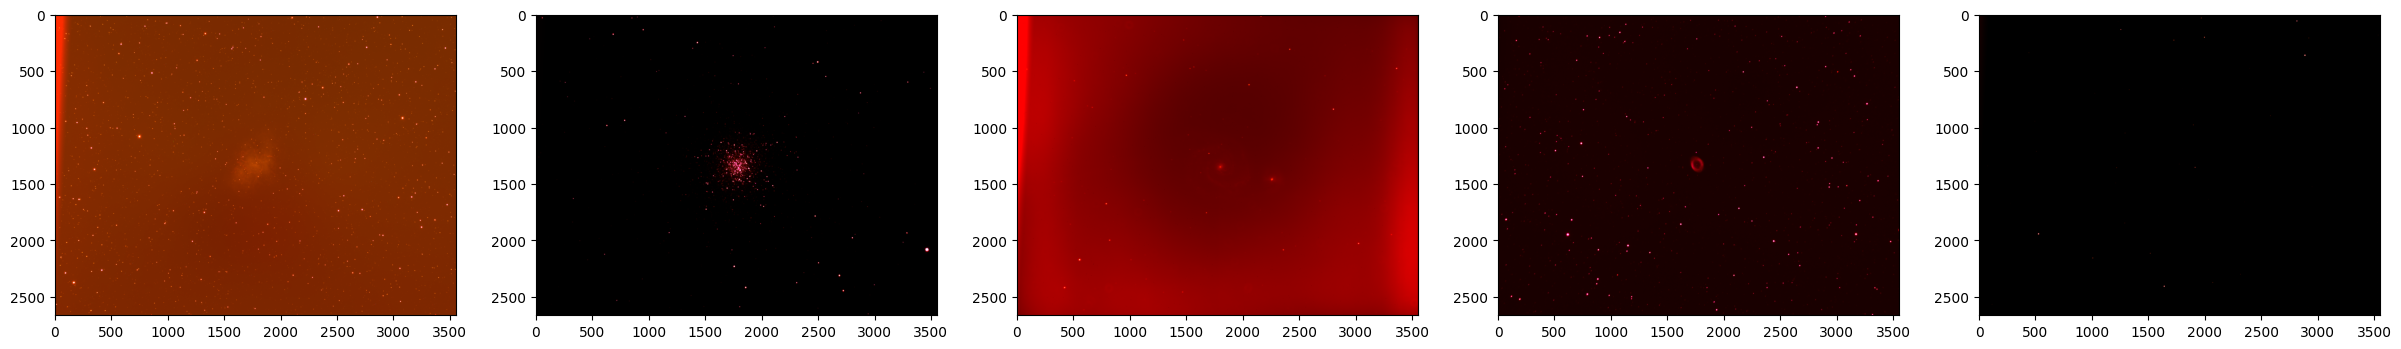

In [9]:
fig, ax = plt.subplots(1, 5, figsize=(30, 30))

for n, i in enumerate(["M 1","M 13","M 51","M 57","M 101"]):

    # Odprimo fits posnetke v vsaki barvi
    R = fits.getdata(os.path.join(folder, "FINAL", i, "R.fits"))
    G = fits.getdata(os.path.join(folder, "FINAL", i, "V.fits"))
    B = fits.getdata(os.path.join(folder, "FINAL", i, "B.fits"))

    # Skalirajmo posnetke
    #R = scale_signal(R, 130, 700)
    #G = scale_signal(G, 120, 900)
    #B = scale_signal(B, 130, 400)

    R = power_scale(R, 130, 700, 1.3)
    G = power_scale(G, 120, 900, 1.3)
    B = power_scale(B, 130, 400, 1.3)

    # Izdelajmo tabelo, ki zdruzi vse tri posnetke v obliko (M,N,3)
    rgb_data=np.dstack([R,G,B])

    # Narisimo sliko
    ax[n].imshow(rgb_data)

Napišimo še kodo, ki nam omogoča interaktivno igranje s spodnjo in zgornjo mejo signala v vsaki barvi.

In [1]:
i = "M 1"
# Odprimo fits posnetke v vsaki barvi
R0 = fits.getdata(os.path.join(folder, "FINAL", i, "R.fits"))
G0 = fits.getdata(os.path.join(folder, "FINAL", i, "V.fits"))
B0 = fits.getdata(os.path.join(folder, "FINAL", i, "B.fits"))

'''R0 = fits.getdata('podatki/Barvna slika/final/H-a.fits')
G0 = fits.getdata('podatki/Barvna slika/final/S II.fits')
B0 = fits.getdata('podatki/Barvna slika/final/O III.fits')



# Funkcija preracuna nove meje vsakic, ko premaknemo drsnik in na novo narise sliko
def update_plot(R_range, G_range, B_range):
    r_low, r_high = R_range
    g_low, g_high = G_range
    b_low, b_high = B_range

    R = power_scale(R0, r_low, r_high, Rgamma_slider)
    G = power_scale(G0, g_low, g_high, Ggamma_slider)
    B = power_scale(B0, b_low, b_high, Bgamma_slider)

    rgb_data = np.dstack([R, G, B])

    plt.figure(figsize=(14,11))
    plt.imshow(rgb_data)
    plt.title('Meglica M27')
    plt.show()
'''


def update_plot_power(R_range, G_range, B_range, Rgamma_slider, Ggamma_slider, Bgamma_slider):
    r_low, r_high = R_range
    g_low, g_high = G_range
    b_low, b_high = B_range

    R = scale_signal(R0, r_low, r_high)
    G = scale_signal(G0, g_low, g_high)
    B = scale_signal(B0, b_low, b_high)

    rgb_data = np.dstack([R, G, B])

    plt.figure(figsize=(14,11))
    plt.imshow(rgb_data)
    plt.title(i)
    plt.show()





# Definicije in postavitve drsnikov
R_slider = widgets.IntRangeSlider(\
    value=[0, 180],\
    min=0, max=2000, step=1,\
    description='Rdeč kanal',\
    layout=widgets.Layout(width='95%'))

Rgamma_slider = widgets.FloatSlider(\
    value= 1.00,\
    min=-2, max=2, step=0.001,\
    description='Gamma R',\
    layout=widgets.Layout(width='95%'))

G_slider = widgets.IntRangeSlider(\
    value=[0, 180],\
    min=0, max=2000, step=1,\
    description='Zelen kanal',\
    layout=widgets.Layout(width='95%'))

Ggamma_slider = widgets.FloatSlider(\
    value= 1.00,\
    min=-2, max=2, step=0.001,\
    description='Gamma G',\
    layout=widgets.Layout(width='95%'))

B_slider = widgets.IntRangeSlider(\
    value=[0,300],\
    min=0, max=2000, step=1,\
    description='Moder kanal',\
    layout=widgets.Layout(width='95%'))

Bgamma_slider = widgets.FloatSlider(\
    value= 1.0,\
    min=-2, max=2, step=0.001,\
    description='Gamma B',\
    layout=widgets.Layout(width='95%'))




# Poveze drsnike s funkcijo, ki rise sliko
interact(update_plot_power, R_range=R_slider, Rgamma_slider=Rgamma_slider, G_range=G_slider, Ggamma_slider=Ggamma_slider, B_range=B_slider, Bgamma_slider=Bgamma_slider)


NameError: name 'fits' is not defined

In [11]:
# Naložimo podatke za vseh 5 objektov
R_data = []
G_data = []
B_data = []
objekti = ["M 1", "M 13", "M 51", "M 57", "M 101"]

for i in objekti:
    R = fits.getdata(os.path.join(folder, "FINAL", i, "R.fits"))
    G = fits.getdata(os.path.join(folder, "FINAL", i, "V.fits"))
    B = fits.getdata(os.path.join(folder, "FINAL", i, "B.fits"))
    R_data.append(R)
    G_data.append(G)
    B_data.append(B)

# Ustvarimo drsnike za vsako sliko posebej
R_sliders = []
G_sliders = []
B_sliders = []
R_gamma_sliders = []
G_gamma_sliders = []
B_gamma_sliders = []

for ime in objekti:
    # Drsniki za meje
    r_slider = widgets.IntRangeSlider(
        value=[0, 2000],
        min=0, max=2000, step=1,
        description=f'{ime} - R (min,max):',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )
    
    g_slider = widgets.IntRangeSlider(
        value=[0, 2000],
        min=0, max=2000, step=1,
        description=f'{ime} - G (min,max):',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )
    
    b_slider = widgets.IntRangeSlider(
        value=[0, 2000],
        min=0, max=2000, step=1,
        description=f'{ime} - B (min,max):',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )
    
    # Drsniki za gamma
    r_gamma = widgets.FloatSlider(
        value=1.0,
        min=0.1, max=3.0, step=0.01,
        description=f'{ime} - γ R:',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )
    
    g_gamma = widgets.FloatSlider(
        value=1.0,
        min=0.1, max=3.0, step=0.01,
        description=f'{ime} - γ G:',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )
    
    b_gamma = widgets.FloatSlider(
        value=1.0,
        min=0.1, max=3.0, step=0.01,
        description=f'{ime} - γ B:',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )
    
    R_sliders.append(r_slider)
    G_sliders.append(g_slider)
    B_sliders.append(b_slider)
    R_gamma_sliders.append(r_gamma)
    G_gamma_sliders.append(g_gamma)
    B_gamma_sliders.append(b_gamma)

# Razporeditev kontrolnikov v mrežo
tabs = []
for i, ime in enumerate(objekti):
    tab = widgets.VBox([
        widgets.HTML(f"<b style='font-size:14px'>{ime}</b>"),
        R_sliders[i],
        G_sliders[i],
        B_sliders[i],
        R_gamma_sliders[i],
        G_gamma_sliders[i],
        B_gamma_sliders[i]
    ])
    tabs.append(tab)

controls_grid = widgets.GridBox(
    tabs,
    layout=widgets.Layout(
        grid_template_columns='repeat(3, 1fr)',
        grid_gap='15px',
        width='100%'
    )
)

# Gumb za osvežitev slik
refresh_button = widgets.Button(
    description='Osveži slike',
    button_style='primary',
    layout=widgets.Layout(width='200px', margin='10px auto')
)

# Izhodni widget za slike
out = widgets.Output()

def update_plots():
    with out:
        clear_output(wait=True)
        
        fig, axes = plt.subplots(2, 5, figsize=(20, 10))
        
        for idx, (ax, ime, ax_his) in enumerate(zip(axes[0], objekti, axes[1])):
            R = R_data[idx]
            G = G_data[idx]
            B = B_data[idx]
            
            # Pridobimo vrednosti drsnikov
            r_min, r_max = R_sliders[idx].value
            g_min, g_max = G_sliders[idx].value
            b_min, b_max = B_sliders[idx].value
            r_gamma = R_gamma_sliders[idx].value
            g_gamma = G_gamma_sliders[idx].value
            b_gamma = B_gamma_sliders[idx].value
            
            # Skaliramo podatke (vedno potenčno skaliranje)
            R_scaled = power_scale(R, r_min, r_max, r_gamma)
            G_scaled = power_scale(G, g_min, g_max, g_gamma)
            B_scaled = power_scale(B, b_min, b_max, b_gamma)
            
            rgb_data = np.dstack([R_scaled, G_scaled, B_scaled])
            
            ax.imshow(rgb_data)
            ax.set_title(ime, fontsize=12)
            ax.axis('off')
            
            
            ax_his.hist((R_scaled.flatten(), G_scaled.flatten(), B_scaled.flatten()), bins = 100, log = True, color= ("r", "g", "b"))
            
            
        
        plt.tight_layout()
        plt.show()

# Ko kliknemo gumb, se slike posodobijo
refresh_button.on_click(lambda btn: update_plots())

# Prikažemo vse
print("\n" + "="*70)
print("PRILAGAJANJE BARVNE UPODOBE - Vsaka slika ima svoje nastavitve")
print("="*70)
print("\nNavodila:")
print("  - Vsaka slika ima svoje drsnike za R, G, B kanale")
print("  - Prilagajaj meje (min, max) in gamma vrednosti")
print("  - Ko nastaviš želene vrednosti, klikni 'Osveži slike'")
print("  - Slike se posodobijo šele po pritisku na gumb\n")

display(controls_grid)
display(refresh_button)
display(out)

# Začetno risanje (da vidimo privzete slike)
update_plots()


PRILAGAJANJE BARVNE UPODOBE - Vsaka slika ima svoje nastavitve

Navodila:
  - Vsaka slika ima svoje drsnike za R, G, B kanale
  - Prilagajaj meje (min, max) in gamma vrednosti
  - Ko nastaviš želene vrednosti, klikni 'Osveži slike'
  - Slike se posodobijo šele po pritisku na gumb



GridBox(children=(VBox(children=(HTML(value="<b style='font-size:14px'>M 1</b>"), IntRangeSlider(value=(0, 200…

Button(button_style='primary', description='Osveži slike', layout=Layout(margin='10px auto', width='200px'), s…

Output()

In [12]:
R = fits.getdata(os.path.join(folder, "FINAL", "M 1", "R.fits"))
G = fits.getdata(os.path.join(folder, "FINAL", "M 1", "V.fits"))
B = fits.getdata(os.path.join(folder, "FINAL", "M 1", "B.fits"))

def power_scale(x, vmin, vmax, a):
    out = np.zeros(x.shape)
    out[x>vmax]=255
    mask = (x>vmin)&(x<vmax)
    out[mask] = 255 * ((x[mask] - vmin)/(vmax - vmin))**a
    return np.array(out, dtype=int)

if True:
    # Drsniki za meje
    r_slider = widgets.IntRangeSlider(
        value=[0, 2000],
        min=0, max=2000, step=1,
        description=f'R (min,max):',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    g_slider = widgets.IntRangeSlider(
        value=[0, 2000],
        min=0, max=2000, step=1,
        description=f'G (min,max):',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    b_slider = widgets.IntRangeSlider(
        value=[0, 2000],
        min=0, max=2000, step=1,
        description=f'B (min,max):',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    # Drsniki za gamma
    r_gamma = widgets.FloatSlider(
        value=1.0,
        min=0.1, max=3.0, step=0.01,
        description=f'γ R:',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    g_gamma = widgets.FloatSlider(
        value=1.0,
        min=0.1, max=3.0, step=0.01,
        description=f'γ G:',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    b_gamma = widgets.FloatSlider(
        value=1.0,
        min=0.1, max=3.0, step=0.01,
        description=f'γ B:',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )


def update_plot(R_range, R_gamma, G_range, G_gamma, B_range, B_gamma):          
      
    # Pridobimo vrednosti drsnikov
    r_min, r_max = R_range
    g_min, g_max = G_range
    b_min, b_max = B_range
    
    # Skaliramo podatke (vedno potenčno skaliranje)
    R_scaled = power_scale(R, r_min, r_max, R_gamma)
    G_scaled = power_scale(G, g_min, g_max, G_gamma)
    B_scaled = power_scale(B, b_min, b_max, B_gamma)
    
    rgb_data = np.dstack([R_scaled, G_scaled, B_scaled])
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(rgb_data)
    axes[0].set_title("M 1", fontsize=12)
    axes[0].axis('off')
    
    
    axes[1].hist((R_scaled.flatten(), G_scaled.flatten(), B_scaled.flatten()), bins = 100, log = True, color= ("r", "g", "b"))
    
    
    #plt.figure(figsize=(14,11))
    #fig.title('Meglica M 1')
    #plt.show()

# Ko kliknemo gumb, se slike posodobijo
interact(update_plot, R_range=r_slider, R_gamma=r_gamma, G_range=g_slider, G_gamma=g_gamma, B_range=b_slider, B_gamma=b_gamma)


interactive(children=(IntRangeSlider(value=(0, 2000), description='R (min,max):', layout=Layout(width='100%'),…

<function __main__.update_plot(R_range, R_gamma, G_range, G_gamma, B_range, B_gamma)>

In [13]:
R = fits.getdata(os.path.join(folder, "FINAL", "M 13", "R.fits"))
G = fits.getdata(os.path.join(folder, "FINAL", "M 13", "V.fits"))
B = fits.getdata(os.path.join(folder, "FINAL", "M 13", "B.fits"))

def power_scale(x, vmin, vmax, a):
    out = np.zeros(x.shape)
    out[x>vmax]=255
    mask = (x>vmin)&(x<vmax)
    out[mask] = 255 * ((x[mask] - vmin)/(vmax - vmin))**a
    return np.array(out, dtype=int)

if True:
    # Drsniki za meje
    r_slider = widgets.IntRangeSlider(
        value=[0, 2000],
        min=0, max=2000, step=1,
        description=f'R (min,max):',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    g_slider = widgets.IntRangeSlider(
        value=[0, 2000],
        min=0, max=2000, step=1,
        description=f'G (min,max):',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    b_slider = widgets.IntRangeSlider(
        value=[0, 2000],
        min=0, max=2000, step=1,
        description=f'B (min,max):',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    # Drsniki za gamma
    r_gamma = widgets.FloatSlider(
        value=1.0,
        min=0.1, max=3.0, step=0.01,
        description=f'γ R:',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    g_gamma = widgets.FloatSlider(
        value=1.0,
        min=0.1, max=3.0, step=0.01,
        description=f'γ G:',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    b_gamma = widgets.FloatSlider(
        value=1.0,
        min=0.1, max=3.0, step=0.01,
        description=f'γ B:',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )


def update_plot(R_range, R_gamma, G_range, G_gamma, B_range, B_gamma):          
      
    # Pridobimo vrednosti drsnikov
    r_min, r_max = R_range
    g_min, g_max = G_range
    b_min, b_max = B_range
    
    # Skaliramo podatke (vedno potenčno skaliranje)
    R_scaled = power_scale(R, r_min, r_max, R_gamma)
    G_scaled = power_scale(G, g_min, g_max, G_gamma)
    B_scaled = power_scale(B, b_min, b_max, B_gamma)
    
    rgb_data = np.dstack([R_scaled, G_scaled, B_scaled])
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(rgb_data)
    axes[0].set_title("M 1", fontsize=12)
    axes[0].axis('off')
    
    
    axes[1].hist((R_scaled.flatten(), G_scaled.flatten(), B_scaled.flatten()), bins = 100, log = True, color= ("r", "g", "b"))
    
    
    #plt.figure(figsize=(14,11))
    #fig.title('Meglica M 1')
    #plt.show()

# Ko kliknemo gumb, se slike posodobijo
interact(update_plot, R_range=r_slider, R_gamma=r_gamma, G_range=g_slider, G_gamma=g_gamma, B_range=b_slider, B_gamma=b_gamma)


interactive(children=(IntRangeSlider(value=(0, 2000), description='R (min,max):', layout=Layout(width='100%'),…

<function __main__.update_plot(R_range, R_gamma, G_range, G_gamma, B_range, B_gamma)>

In [14]:
R = fits.getdata(os.path.join(folder, "FINAL", "M 51", "R.fits"))
G = fits.getdata(os.path.join(folder, "FINAL", "M 51", "V.fits"))
B = fits.getdata(os.path.join(folder, "FINAL", "M 51", "B.fits"))

def power_scale(x, vmin, vmax, a):
    out = np.zeros(x.shape)
    out[x>vmax]=255
    mask = (x>vmin)&(x<vmax)
    out[mask] = 255 * ((x[mask] - vmin)/(vmax - vmin))**a
    return np.array(out, dtype=int)

if True:
    # Drsniki za meje
    r_slider = widgets.IntRangeSlider(
        value=[0, 2000],
        min=0, max=2000, step=1,
        description=f'R (min,max):',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    g_slider = widgets.IntRangeSlider(
        value=[0, 2000],
        min=0, max=2000, step=1,
        description=f'G (min,max):',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    b_slider = widgets.IntRangeSlider(
        value=[0, 2000],
        min=0, max=2000, step=1,
        description=f'B (min,max):',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    # Drsniki za gamma
    r_gamma = widgets.FloatSlider(
        value=1.0,
        min=0.1, max=3.0, step=0.01,
        description=f'γ R:',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    g_gamma = widgets.FloatSlider(
        value=1.0,
        min=0.1, max=3.0, step=0.01,
        description=f'γ G:',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    b_gamma = widgets.FloatSlider(
        value=1.0,
        min=0.1, max=3.0, step=0.01,
        description=f'γ B:',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )


def update_plot(R_range, R_gamma, G_range, G_gamma, B_range, B_gamma):          
      
    # Pridobimo vrednosti drsnikov
    r_min, r_max = R_range
    g_min, g_max = G_range
    b_min, b_max = B_range
    
    # Skaliramo podatke (vedno potenčno skaliranje)
    R_scaled = power_scale(R, r_min, r_max, R_gamma)
    G_scaled = power_scale(G, g_min, g_max, G_gamma)
    B_scaled = power_scale(B, b_min, b_max, B_gamma)
    
    rgb_data = np.dstack([R_scaled, G_scaled, B_scaled])
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(rgb_data)
    axes[0].set_title("M 1", fontsize=12)
    axes[0].axis('off')
    
    
    axes[1].hist((R_scaled.flatten(), G_scaled.flatten(), B_scaled.flatten()), bins = 100, log = True, color= ("r", "g", "b"))
    
    
    #plt.figure(figsize=(14,11))
    #fig.title('Meglica M 1')
    #plt.show()

# Ko kliknemo gumb, se slike posodobijo
interact(update_plot, R_range=r_slider, R_gamma=r_gamma, G_range=g_slider, G_gamma=g_gamma, B_range=b_slider, B_gamma=b_gamma)


interactive(children=(IntRangeSlider(value=(0, 2000), description='R (min,max):', layout=Layout(width='100%'),…

<function __main__.update_plot(R_range, R_gamma, G_range, G_gamma, B_range, B_gamma)>

In [ ]:
R = fits.getdata(os.path.join(folder, "FINAL", "M 57", "R.fits"))
G = fits.getdata(os.path.join(folder, "FINAL", "M 57", "V.fits"))
B = fits.getdata(os.path.join(folder, "FINAL", "M 57", "B.fits"))

def power_scale(x, vmin, vmax, a):
    out = np.zeros(x.shape)
    out[x>vmax]=255
    mask = (x>vmin)&(x<vmax)
    out[mask] = 255 * ((x[mask] - vmin)/(vmax - vmin))**a
    return np.array(out, dtype=int)

if True:
    # Drsniki za meje
    r_slider = widgets.IntRangeSlider(
        value=[0, 2000],
        min=0, max=2000, step=1,
        description=f'R (min,max):',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    g_slider = widgets.IntRangeSlider(
        value=[0, 2000],
        min=0, max=2000, step=1,
        description=f'G (min,max):',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    b_slider = widgets.IntRangeSlider(
        value=[0, 2000],
        min=0, max=2000, step=1,
        description=f'B (min,max):',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    # Drsniki za gamma
    r_gamma = widgets.FloatSlider(
        value=1.0,
        min=0.1, max=3.0, step=0.01,
        description=f'γ R:',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    g_gamma = widgets.FloatSlider(
        value=1.0,
        min=0.1, max=3.0, step=0.01,
        description=f'γ G:',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    b_gamma = widgets.FloatSlider(
        value=1.0,
        min=0.1, max=3.0, step=0.01,
        description=f'γ B:',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )


def update_plot(R_range, R_gamma, G_range, G_gamma, B_range, B_gamma):          
      
    # Pridobimo vrednosti drsnikov
    r_min, r_max = R_range
    g_min, g_max = G_range
    b_min, b_max = B_range
    
    # Skaliramo podatke (vedno potenčno skaliranje)
    R_scaled = power_scale(R, r_min, r_max, R_gamma)
    G_scaled = power_scale(G, g_min, g_max, G_gamma)
    B_scaled = power_scale(B, b_min, b_max, B_gamma)
    
    rgb_data = np.dstack([R_scaled, G_scaled, B_scaled])
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(rgb_data)
    axes[0].set_title("M 1", fontsize=12)
    axes[0].axis('off')
    
    
    axes[1].hist((R_scaled.flatten(), G_scaled.flatten(), B_scaled.flatten()), bins = 100, log = True, color= ("r", "g", "b"))
    
    
    #plt.figure(figsize=(14,11))
    #fig.title('Meglica M 1')
    #plt.show()

# Ko kliknemo gumb, se slike posodobijo
interact(update_plot, R_range=r_slider, R_gamma=r_gamma, G_range=g_slider, G_gamma=g_gamma, B_range=b_slider, B_gamma=b_gamma)


interactive(children=(IntRangeSlider(value=(0, 2000), description='R (min,max):', layout=Layout(width='100%'),…

<function __main__.update_plot(R_range, R_gamma, G_range, G_gamma, B_range, B_gamma)>

In [17]:
R = fits.getdata(os.path.join(folder, "FINAL", "M 101", "R.fits"))
G = fits.getdata(os.path.join(folder, "FINAL", "M 101", "V.fits"))
B = fits.getdata(os.path.join(folder, "FINAL", "M 101", "B.fits"))

def power_scale(x, vmin, vmax, a):
    out = np.zeros(x.shape)
    out[x>vmax]=255
    mask = (x>vmin)&(x<vmax)
    out[mask] = 255 * ((x[mask] - vmin)/(vmax - vmin))**a
    return np.array(out, dtype=int)

if True:
    # Drsniki za meje
    r_slider = widgets.IntRangeSlider(
        value=[0, 2000],
        min=0, max=2000, step=1,
        description=f'R (min,max):',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    g_slider = widgets.IntRangeSlider(
        value=[0, 2000],
        min=0, max=2000, step=1,
        description=f'G (min,max):',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    b_slider = widgets.IntRangeSlider(
        value=[0, 2000],
        min=0, max=2000, step=1,
        description=f'B (min,max):',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    # Drsniki za gamma
    r_gamma = widgets.FloatSlider(
        value=1.0,
        min=0.1, max=3.0, step=0.01,
        description=f'γ R:',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    g_gamma = widgets.FloatSlider(
        value=1.0,
        min=0.1, max=3.0, step=0.01,
        description=f'γ G:',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )

    b_gamma = widgets.FloatSlider(
        value=1.0,
        min=0.1, max=3.0, step=0.01,
        description=f'γ B:',
        layout=widgets.Layout(width='100%'),
        style={'description_width': 'initial'}
    )


def update_plot(R_range, R_gamma, G_range, G_gamma, B_range, B_gamma):          
      
    # Pridobimo vrednosti drsnikov
    r_min, r_max = R_range
    g_min, g_max = G_range
    b_min, b_max = B_range
    
    # Skaliramo podatke (vedno potenčno skaliranje)
    R_scaled = power_scale(R, r_min, r_max, R_gamma)
    G_scaled = power_scale(G, g_min, g_max, G_gamma)
    B_scaled = power_scale(B, b_min, b_max, B_gamma)
    
    rgb_data = np.dstack([R_scaled, G_scaled, B_scaled])
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(rgb_data)
    axes[0].set_title("M 1", fontsize=12)
    axes[0].axis('off')
    
    
    axes[1].hist((R_scaled.flatten(), G_scaled.flatten(), B_scaled.flatten()), bins = 100, log = True, color= ("r", "g", "b"))
    
    
    #plt.figure(figsize=(14,11))
    #fig.title('Meglica M 1')
    #plt.show()

# Ko kliknemo gumb, se slike posodobijo
interact(update_plot, R_range=r_slider, R_gamma=r_gamma, G_range=g_slider, G_gamma=g_gamma, B_range=b_slider, B_gamma=b_gamma)


interactive(children=(IntRangeSlider(value=(0, 2000), description='R (min,max):', layout=Layout(width='100%'),…

<function __main__.update_plot(R_range, R_gamma, G_range, G_gamma, B_range, B_gamma)>

## Vprašanja

 * Zakaj je flat posnetek v R filtru toliko krajši od drugih?
 * Zakaj raje posnamemo več kratkih ekspozicij, kot eno dolgo?
 * Zakaj ima barvna slika, ki jo naredimo z uporabo H$\alpha$, V in O III posnetka bolj žive barve od slike, ki jo naredimo z R, V in B posnetki?
 * V programih za obdelavo slik lahko barvam spreminjamo saturacijo. Kako je parameter saturacije matematično implementiran?